# Proyek Klasifikasi Gambar: [Garbage Classification]

## Import Semua Packages/Library yang Digunakan

In [2]:
import sys
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
import splitfolders
import tensorflowjs as tfjs
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam

c:\Users\Vincent\Documents\Coding\Dicoding\Bootcamp\KlasifikasiGambar\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Preparation

### Data Loading

In [6]:
path = kagglehub.dataset_download("nishchalkansara/garbage-classification")

def find_data_dir(root_path):
    for root, dirs, files in os.walk(root_path):
        if len(dirs) > 5:
            return root
    return root_path

data_source = find_data_dir(path)

base_final = "dataset_final"
if os.path.exists(base_final):
    shutil.rmtree(base_final)

### Data Preprocessing

#### Split Dataset

In [7]:
splitfolders.ratio(data_source, output=base_final, seed=1337, ratio=(.8, .1, .1))

train_dir = os.path.join(base_final, 'train')
val_dir = os.path.join(base_final, 'val')
test_dir = os.path.join(base_final, 'test')

classes = sorted(os.listdir(train_dir))

Copying files: 12378 files [00:22, 552.62 files/s]


In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 9898 images belonging to 11 classes.
Found 1233 images belonging to 11 classes.
Found 1247 images belonging to 11 classes.


## Modelling

In [20]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = Sequential([
    base_model,
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                                 
 conv2d_9 (Conv2D)           (None, 5, 5, 128)         1474688   
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 2, 2, 128)        0         
 2D)                                                             
                                                                 
 global_average_pooling2d_8   (None, 128)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_15 (Dense)            (None, 512)               66048     
                                                      

In [21]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

In [22]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
310/310 [==============================] - 101s 321ms/step - loss: 0.6727 - accuracy: 0.7689 - val_loss: 0.3471 - val_accuracy: 0.8670 - lr: 1.0000e-04
Epoch 2/20
310/310 [==============================] - 90s 289ms/step - loss: 0.4074 - accuracy: 0.8449 - val_loss: 0.3205 - val_accuracy: 0.8621 - lr: 1.0000e-04
Epoch 3/20
310/310 [==============================] - 89s 287ms/step - loss: 0.3433 - accuracy: 0.8604 - val_loss: 0.2973 - val_accuracy: 0.8662 - lr: 1.0000e-04
Epoch 4/20
310/310 [==============================] - 87s 281ms/step - loss: 0.3196 - accuracy: 0.8688 - val_loss: 0.3108 - val_accuracy: 0.8719 - lr: 1.0000e-04
Epoch 5/20
310/310 [==============================] - 86s 278ms/step - loss: 0.2873 - accuracy: 0.8786 - val_loss: 0.2931 - val_accuracy: 0.8637 - lr: 1.0000e-04
Epoch 6/20
310/310 [==============================] - 87s 280ms/step - loss: 0.2658 - accuracy: 0.8813 - val_loss: 0.2814 - val_accuracy: 0.8735 - lr: 1.0000e-04
Epoch 7/20
310/310 [=======

## Evaluasi dan Visualisasi

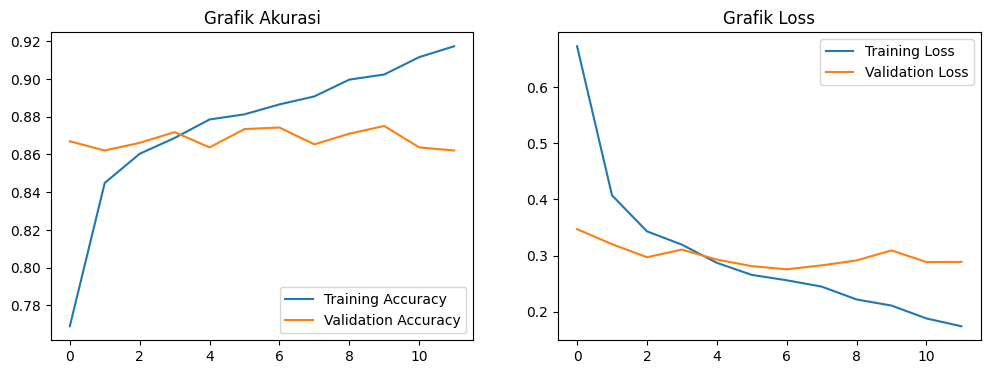

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Grafik Loss')
plt.legend(loc='upper right')
plt.show()

39/39 [==============================] - 9s 221ms/step - loss: 0.3009 - accuracy: 0.8645
Akurasi pada Data Test: 86.45%
39/39 [==============================] - 10s 223ms/step

Classification Report
              precision    recall  f1-score   support

     battery       0.97      1.00      0.99        78
  biological       0.50      0.55      0.53       101
   cardboard       0.79      0.80      0.80        41
     clothes       0.98      0.99      0.98       534
       glass       0.89      0.65      0.75        51
       metal       0.69      0.93      0.79        41
     organic       0.38      0.36      0.37        78
       paper       0.87      0.80      0.83        60
     plastic       0.88      0.71      0.79        49
       shoes       0.96      0.97      0.97       199
       trash       0.62      0.53      0.57        15

    accuracy                           0.86      1247
   macro avg       0.78      0.75      0.76      1247
weighted avg       0.87      0.86      0.86

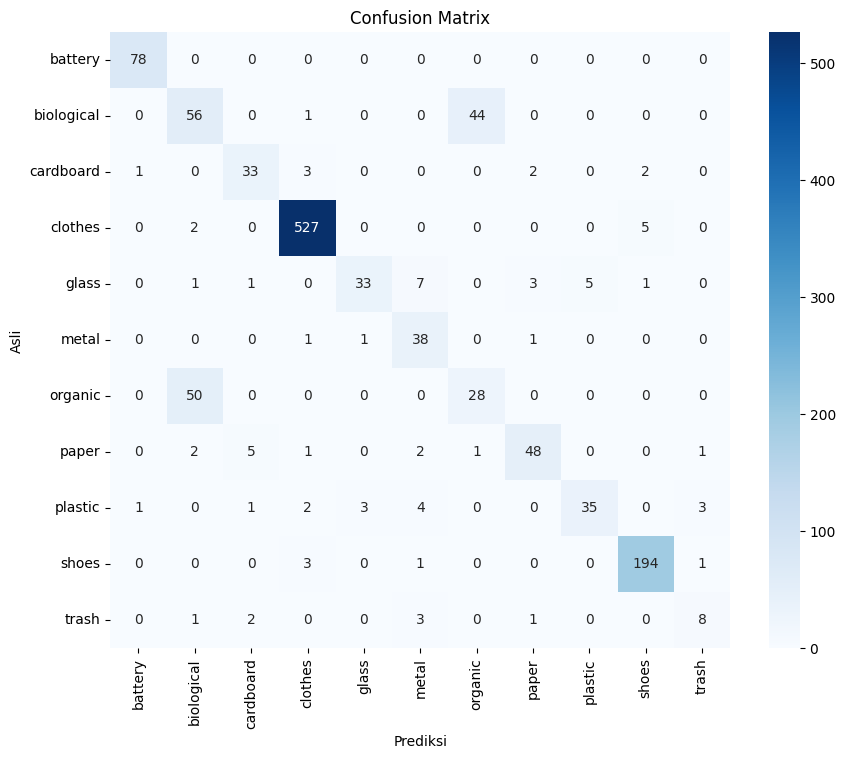

In [24]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Akurasi pada Data Test: {test_acc*100:.2f}%")

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

print('\nClassification Report')

print(classification_report(test_generator.classes, y_pred, target_names=classes))
plt.figure(figsize=(10, 8))
cm = confusion_matrix(test_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Asli')
plt.title('Confusion Matrix')
plt.show()

## Konversi Model

In [25]:
export_dir = 'submission'
os.makedirs(export_dir, exist_ok=True)

model.save(os.path.join(export_dir, 'saved_model'))

tflite_dir = os.path.join(export_dir, 'tflite')
os.makedirs(tflite_dir, exist_ok=True)
converter = tf.lite.TFLiteConverter.from_saved_model(os.path.join(export_dir, 'saved_model'))
with open(os.path.join(tflite_dir, 'model.tflite'), 'wb') as f:
    f.write(converter.convert())

with open(os.path.join(tflite_dir, 'label.txt'), 'w') as f:
    for label in sorted(train_generator.class_indices.keys()):
        f.write(f"{label}\n")

tfjs.converters.save_keras_model(model, os.path.join(export_dir, 'tfjs_model'))

!pip freeze > {os.path.join(export_dir, 'requirements.txt')}

INFO:tensorflow:Assets written to: submission\saved_model\assets


INFO:tensorflow:Assets written to: submission\saved_model\assets


## Inference (Optional)

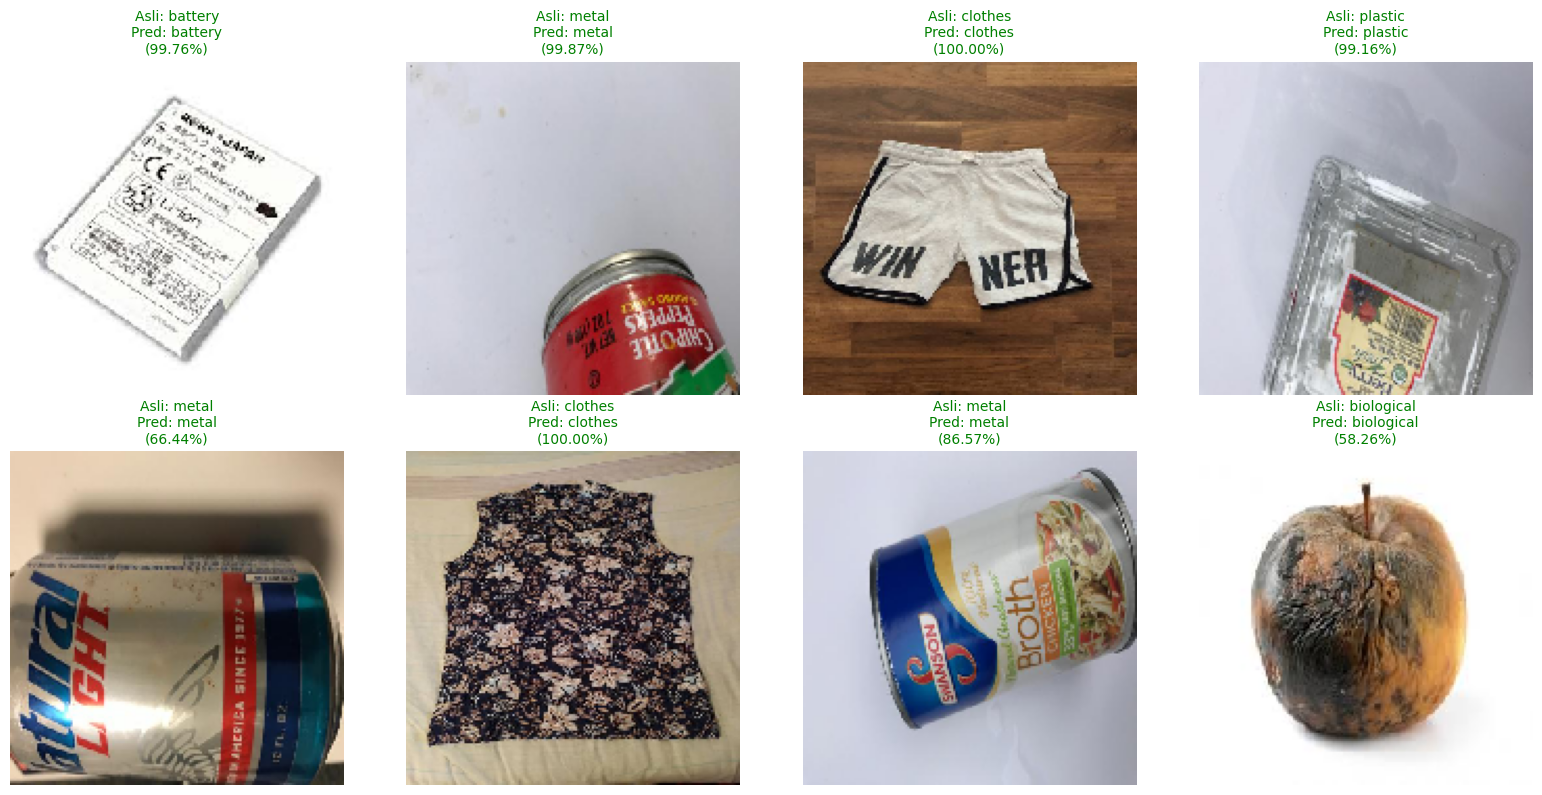

In [34]:
num_images = 8
plt.figure(figsize=(16, 8))

for i in range(num_images):
    random_class = random.choice(classes)
    folder_path = os.path.join(test_dir, random_class)
    random_file = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, random_file)
    img = image.load_img(img_path, target_size=(160, 160))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x, verbose=0)
    pred_class = classes[np.argmax(preds)]
    confidence = np.max(preds) * 100
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    title_color = 'green' if pred_class == random_class else 'red'
    plt.title(f"Asli: {random_class}\nPred: {pred_class}\n({confidence:.2f}%)", 
              color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()